# Part 2: t-SNE and PCA Comparison on MNIST Dataset

This notebook applies and compares t-Distributed Stochastic Neighbor Embedding (t-SNE) and Principal Component Analysis (PCA) for dimensionality reduction and visualization on the MNIST dataset.

## Objectives:
1. Load MNIST dataset
2. Apply PCA for dimensionality reduction
3. Apply t-SNE for visualization
4. Compare the two methods
5. Analyze how well each method preserves data structure

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import time
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

## 2. Load MNIST Dataset

We'll use a subset of MNIST for faster computation while still demonstrating the concepts.

In [2]:
# Load MNIST dataset
print("Loading MNIST dataset...")
mnist = fetch_openml('mnist_784', version=1, parser='auto')
X, y = mnist.data, mnist.target

# Convert to numpy arrays and correct types
X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int32)

print(f"Original dataset shape: {X.shape}")
print(f"Number of classes: {len(np.unique(y))}")

# Use a subset for faster processing (first 5000 samples)
n_samples = 5000
X_subset = X[:n_samples]
y_subset = y[:n_samples]

print(f"\nUsing subset: {X_subset.shape}")
print(f"Labels distribution:")
print(pd.Series(y_subset).value_counts().sort_index())

Loading MNIST dataset...
Original dataset shape: (70000, 784)
Number of classes: 10

Using subset: (5000, 784)
Labels distribution:
0    479
1    563
2    488
3    493
4    535
5    434
6    501
7    550
8    462
9    495
Name: count, dtype: int64


## 3. Visualize Sample Images

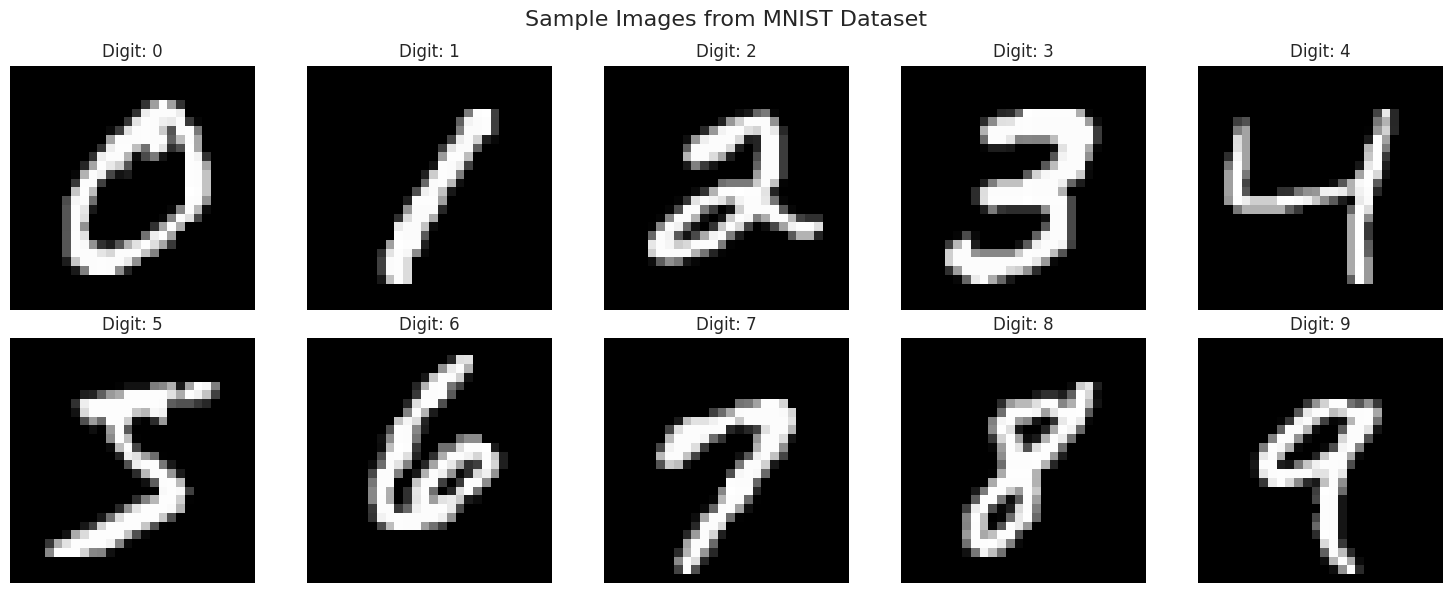

In [3]:
# Display sample images from each digit class
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for digit in range(10):
    # Find first occurrence of each digit
    idx = np.where(y_subset == digit)[0][0]
    img = X_subset[idx].reshape(28, 28)
    
    axes[digit].imshow(img, cmap='gray')
    axes[digit].set_title(f'Digit: {digit}')
    axes[digit].axis('off')

plt.suptitle('Sample Images from MNIST Dataset', fontsize=16)
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

Scale the data before applying dimensionality reduction.

In [4]:
# Normalize the data (pixel values are 0-255)
X_normalized = X_subset / 255.0

print(f"Data normalized. Shape: {X_normalized.shape}")
print(f"Min value: {X_normalized.min()}, Max value: {X_normalized.max()}")

Data normalized. Shape: (5000, 784)
Min value: 0.0, Max value: 1.0


## 5. Apply PCA

PCA is a linear dimensionality reduction technique that finds orthogonal components explaining maximum variance.

Applying PCA...
PCA completed in 0.09 seconds
Explained variance ratio: [0.09867556 0.07404539]
Total variance explained: 0.1727


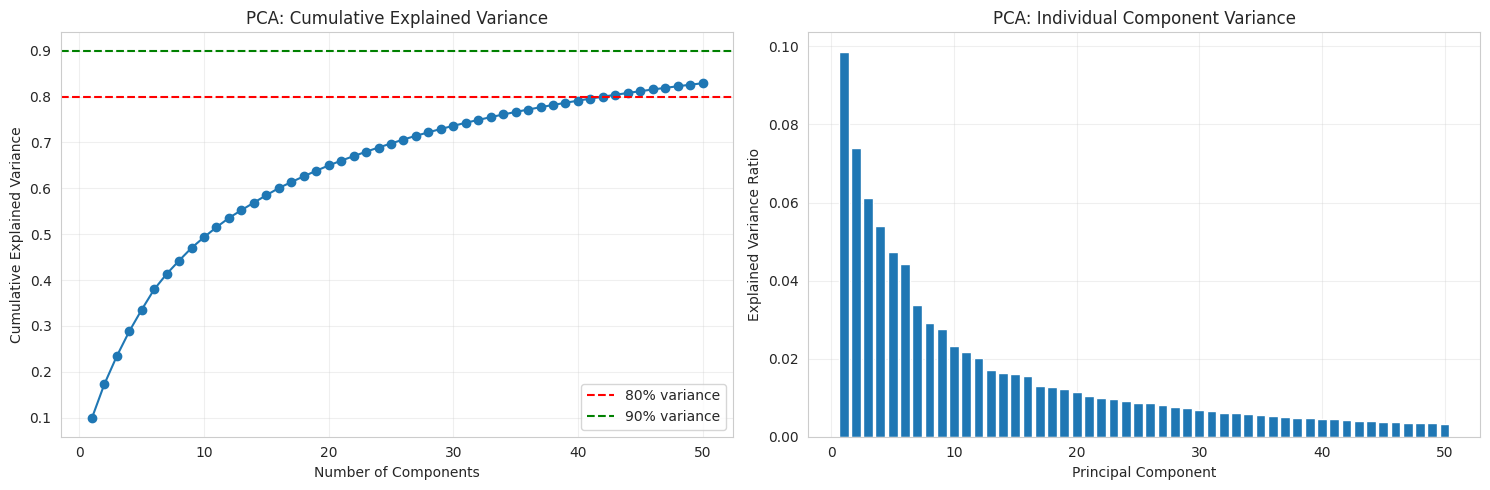


Number of components needed for 90% variance: 1


In [5]:
# Apply PCA to reduce to 2D for visualization
print("Applying PCA...")
start_time = time.time()

pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_normalized)

pca_time = time.time() - start_time

print(f"PCA completed in {pca_time:.2f} seconds")
print(f"Explained variance ratio: {pca_2d.explained_variance_ratio_}")
print(f"Total variance explained: {pca_2d.explained_variance_ratio_.sum():.4f}")

# Also apply PCA to multiple dimensions to see variance curve
pca_50 = PCA(n_components=50, random_state=42)
pca_50.fit(X_normalized)

# Plot explained variance
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Cumulative variance
cumsum_var = np.cumsum(pca_50.explained_variance_ratio_)
axes[0].plot(range(1, 51), cumsum_var, marker='o')
axes[0].set_xlabel('Number of Components')
axes[0].set_ylabel('Cumulative Explained Variance')
axes[0].set_title('PCA: Cumulative Explained Variance')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0.8, color='r', linestyle='--', label='80% variance')
axes[0].axhline(y=0.9, color='g', linestyle='--', label='90% variance')
axes[0].legend()

# Individual variance
axes[1].bar(range(1, 51), pca_50.explained_variance_ratio_)
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Explained Variance Ratio')
axes[1].set_title('PCA: Individual Component Variance')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find number of components needed for 90% variance
n_components_90 = np.argmax(cumsum_var >= 0.9) + 1
print(f"\nNumber of components needed for 90% variance: {n_components_90}")

## 6. Visualize PCA Results

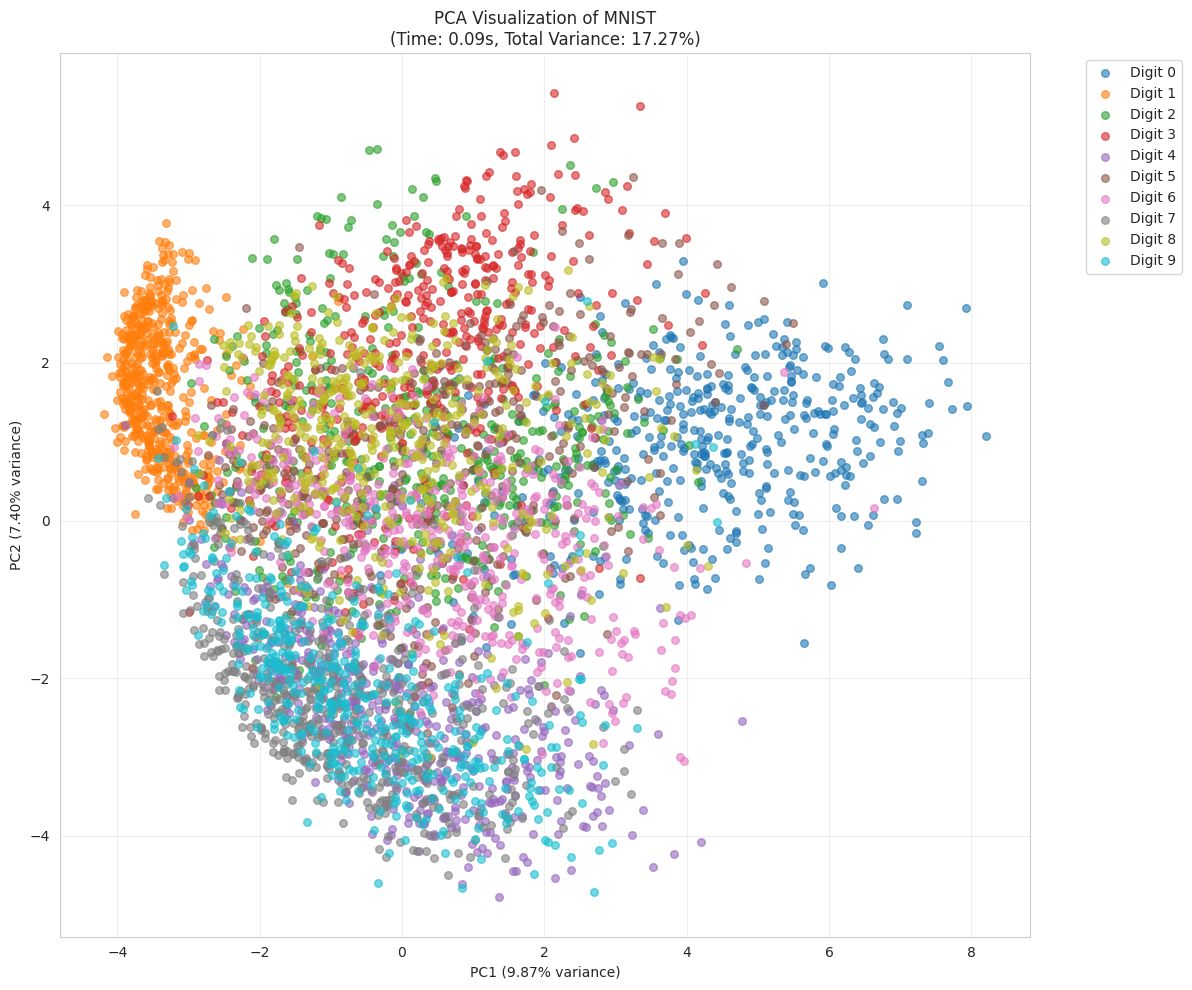

In [6]:
# Visualize PCA 2D projection
plt.figure(figsize=(12, 10))

# Create a color map for the 10 digits
colors = plt.cm.tab10(np.linspace(0, 1, 10))

for digit in range(10):
    mask = y_subset == digit
    plt.scatter(
        X_pca_2d[mask, 0],
        X_pca_2d[mask, 1],
        c=[colors[digit]],
        label=f'Digit {digit}',
        alpha=0.6,
        s=30
    )

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%} variance)')
plt.title(f'PCA Visualization of MNIST\n(Time: {pca_time:.2f}s, Total Variance: {pca_2d.explained_variance_ratio_.sum():.2%})')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Apply t-SNE

t-SNE is a non-linear dimensionality reduction technique that preserves local structure well.

In [8]:
# Apply t-SNE with default perplexity
print("Applying t-SNE (this may take a while)...")
start_time = time.time()

tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000, verbose=1)
X_tsne = tsne.fit_transform(X_normalized)

tsne_time = time.time() - start_time

print(f"\nt-SNE completed in {tsne_time:.2f} seconds")
print(f"Final KL divergence: {tsne.kl_divergence_:.4f}")

Applying t-SNE (this may take a while)...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 5000 samples in 0.013s...


[t-SNE] Computed neighbors for 5000 samples in 1.791s...
[t-SNE] Computed conditional probabilities for sample 1000 / 5000
[t-SNE] Computed conditional probabilities for sample 2000 / 5000
[t-SNE] Computed conditional probabilities for sample 3000 / 5000
[t-SNE] Computed conditional probabilities for sample 4000 / 5000
[t-SNE] Computed conditional probabilities for sample 5000 / 5000
[t-SNE] Mean sigma: 2.226847
[t-SNE] KL divergence after 250 iterations with early exaggeration: 81.832642
[t-SNE] KL divergence after 1000 iterations: 1.459409

t-SNE completed in 20.77 seconds
Final KL divergence: 1.4594


## 8. Visualize t-SNE Results

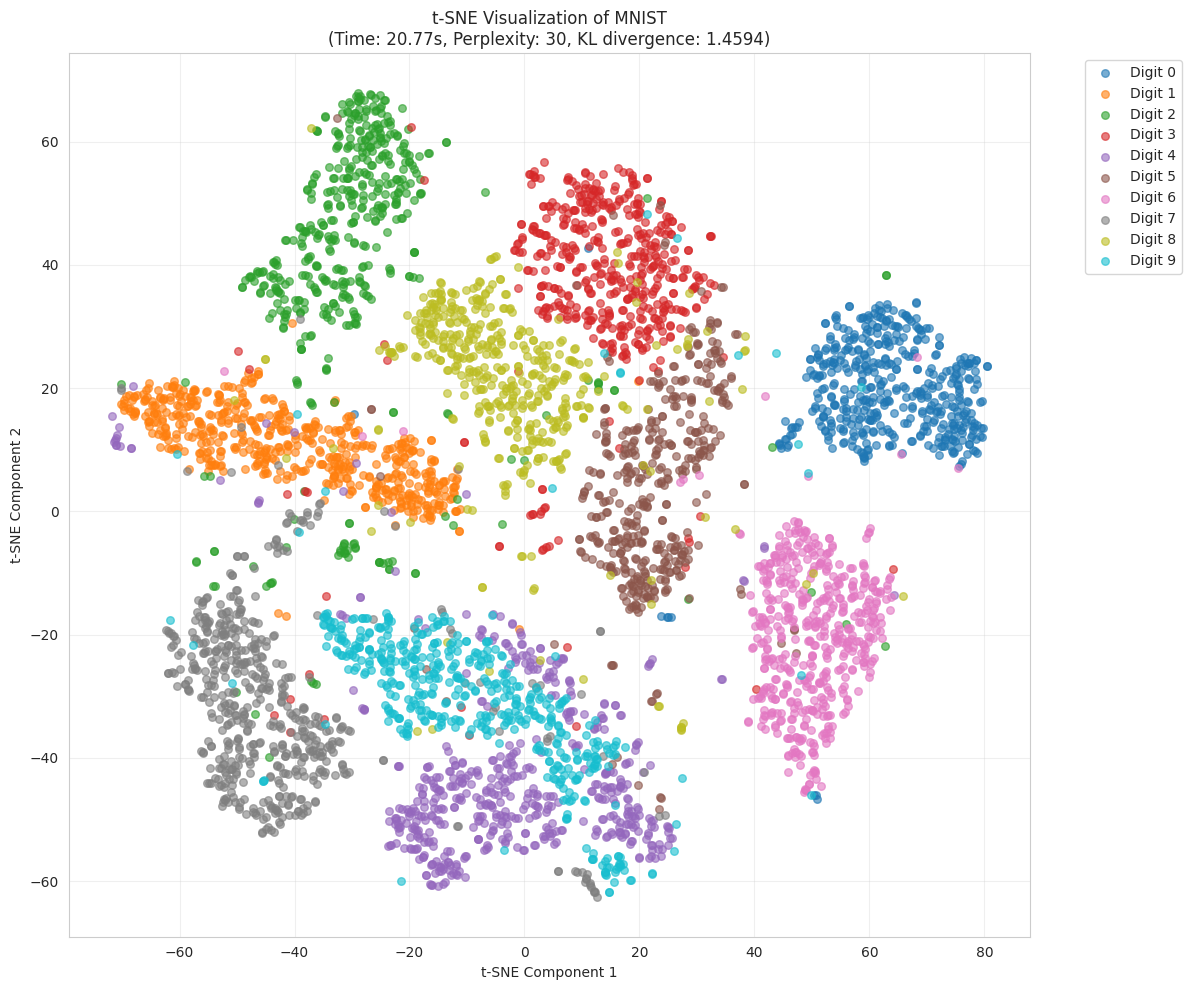

In [9]:
# Visualize t-SNE 2D projection
plt.figure(figsize=(12, 10))

# Use the same color map
colors = plt.cm.tab10(np.linspace(0, 1, 10))

for digit in range(10):
    mask = y_subset == digit
    plt.scatter(
        X_tsne[mask, 0],
        X_tsne[mask, 1],
        c=[colors[digit]],
        label=f'Digit {digit}',
        alpha=0.6,
        s=30
    )

plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title(f't-SNE Visualization of MNIST\n(Time: {tsne_time:.2f}s, Perplexity: 30, KL divergence: {tsne.kl_divergence_:.4f})')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Effect of Perplexity on t-SNE

The perplexity parameter balances local vs global structure. Let's explore different values.

In [11]:
# Try different perplexity values
perplexities = [5, 30, 50, 100]
tsne_results = []

for perp in perplexities:
    print(f"\nApplying t-SNE with perplexity={perp}...")
    start = time.time()
    
    tsne_model = TSNE(n_components=2, random_state=42, perplexity=perp, max_iter=1000)
    X_transformed = tsne_model.fit_transform(X_normalized)
    
    elapsed = time.time() - start
    
    tsne_results.append({
        'perplexity': perp,
        'X_transformed': X_transformed,
        'time': elapsed,
        'kl_divergence': tsne_model.kl_divergence_
    })
    
    print(f"  Time: {elapsed:.2f}s, KL divergence: {tsne_model.kl_divergence_:.4f}")


Applying t-SNE with perplexity=5...


  Time: 16.52s, KL divergence: 1.5574

Applying t-SNE with perplexity=30...
  Time: 16.56s, KL divergence: 1.4594

Applying t-SNE with perplexity=50...
  Time: 18.78s, KL divergence: 1.3883

Applying t-SNE with perplexity=100...
  Time: 23.26s, KL divergence: 1.2573


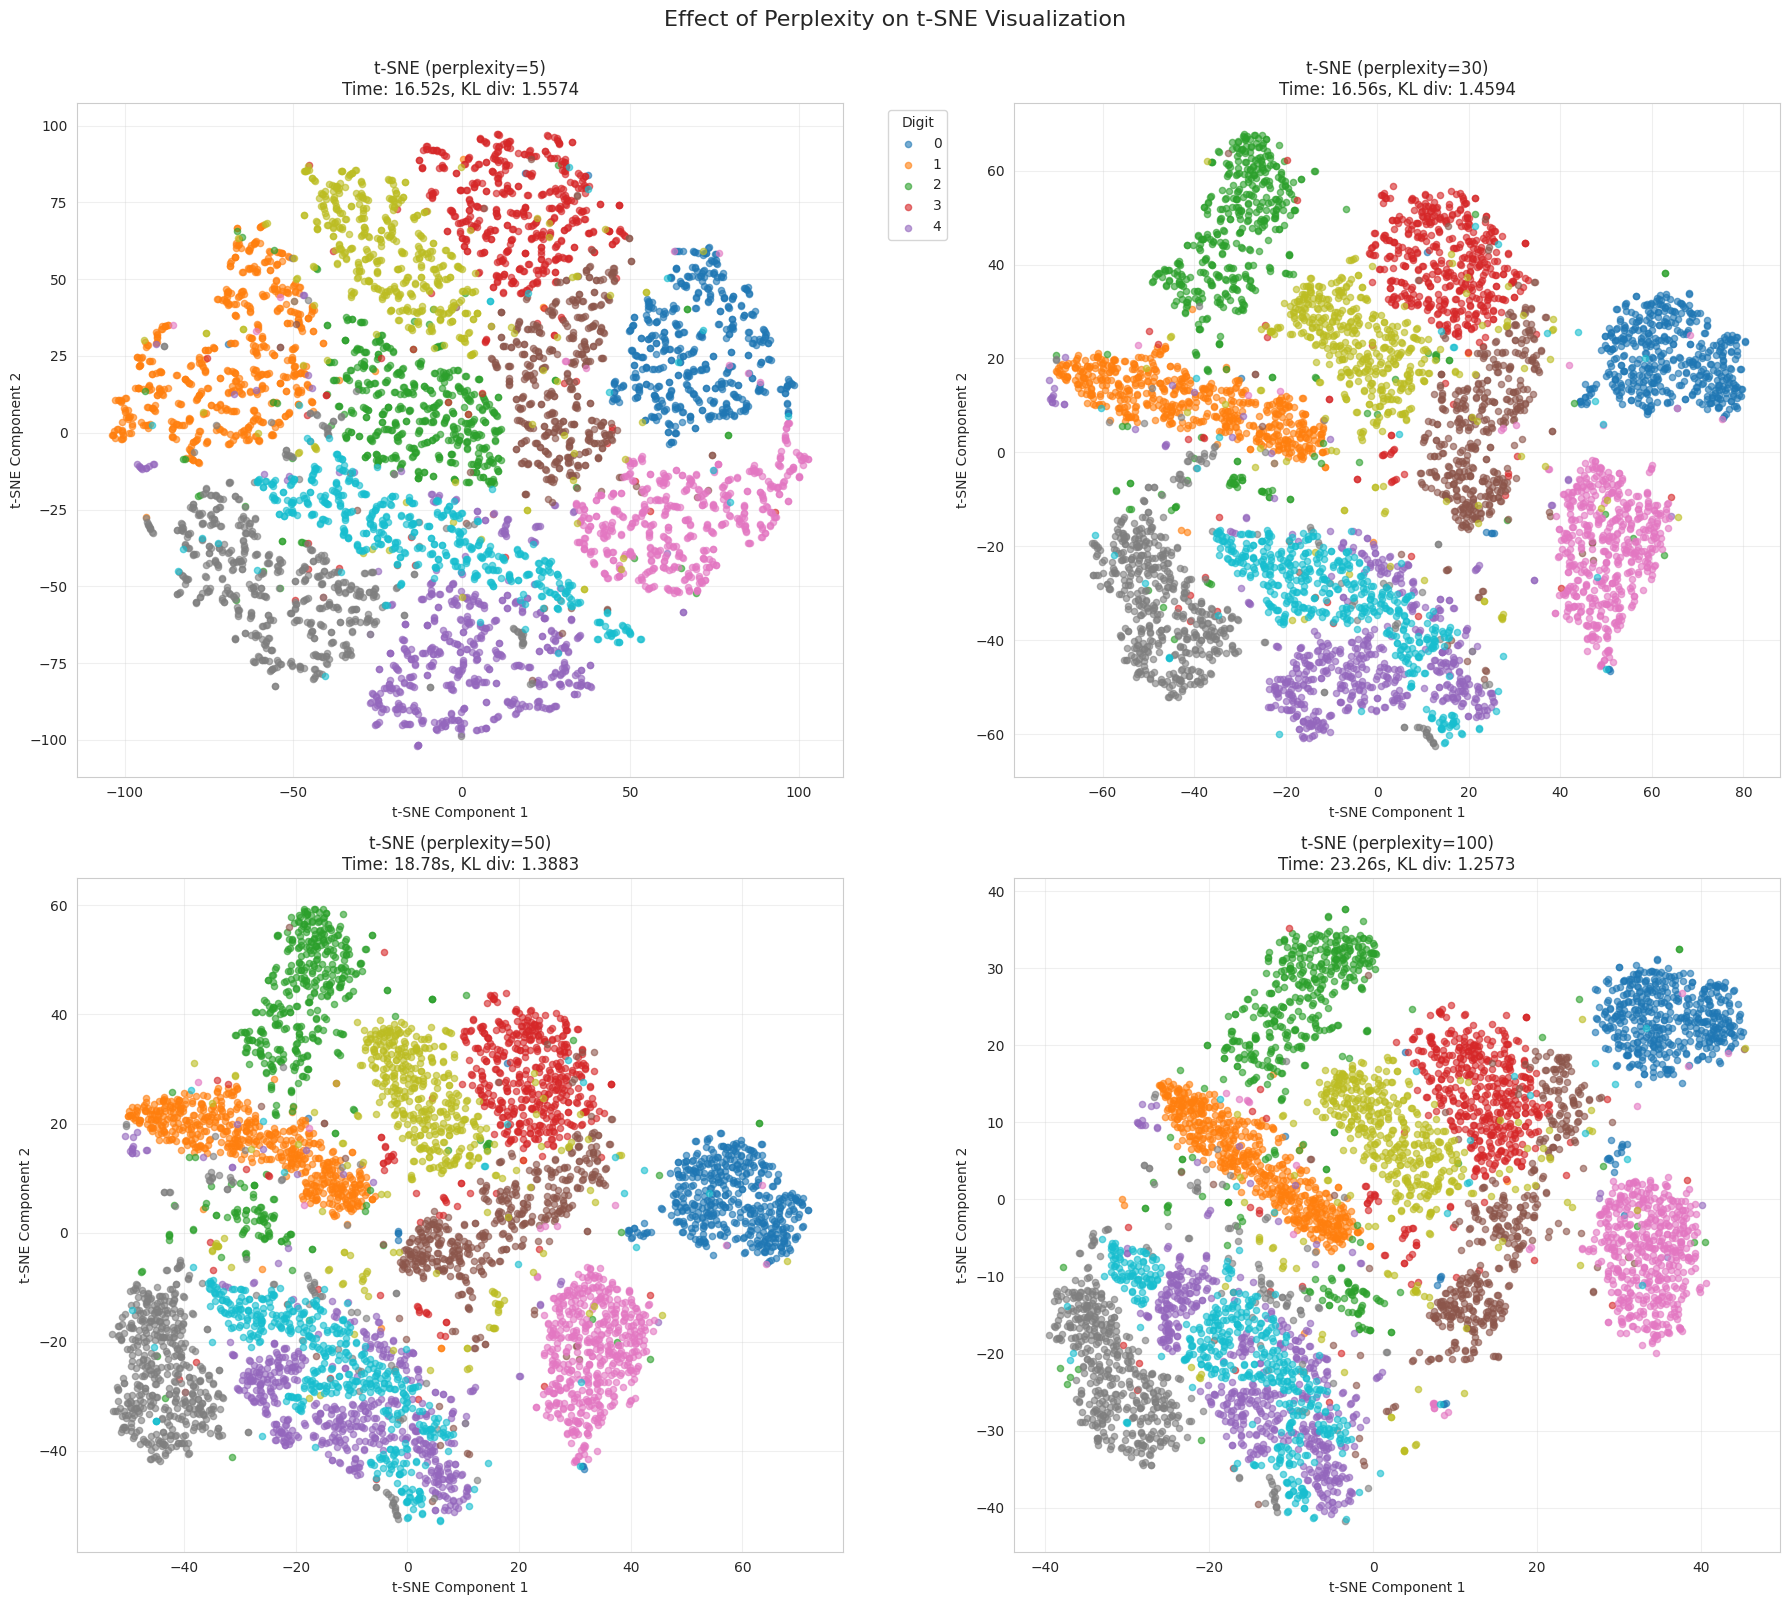

In [12]:
# Visualize different perplexity results
fig, axes = plt.subplots(2, 2, figsize=(18, 16))
axes = axes.ravel()

colors = plt.cm.tab10(np.linspace(0, 1, 10))

for idx, result in enumerate(tsne_results):
    X_trans = result['X_transformed']
    
    for digit in range(10):
        mask = y_subset == digit
        axes[idx].scatter(
            X_trans[mask, 0],
            X_trans[mask, 1],
            c=[colors[digit]],
            label=f'{digit}' if digit < 5 else None,  # Only label first 5 to avoid clutter
            alpha=0.6,
            s=20
        )
    
    axes[idx].set_xlabel('t-SNE Component 1')
    axes[idx].set_ylabel('t-SNE Component 2')
    axes[idx].set_title(
        f"t-SNE (perplexity={result['perplexity']})\n"
        f"Time: {result['time']:.2f}s, KL div: {result['kl_divergence']:.4f}"
    )
    axes[idx].grid(True, alpha=0.3)
    if idx == 0:
        axes[idx].legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Digit')

plt.suptitle('Effect of Perplexity on t-SNE Visualization', fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

## 10. Side-by-Side Comparison: PCA vs t-SNE

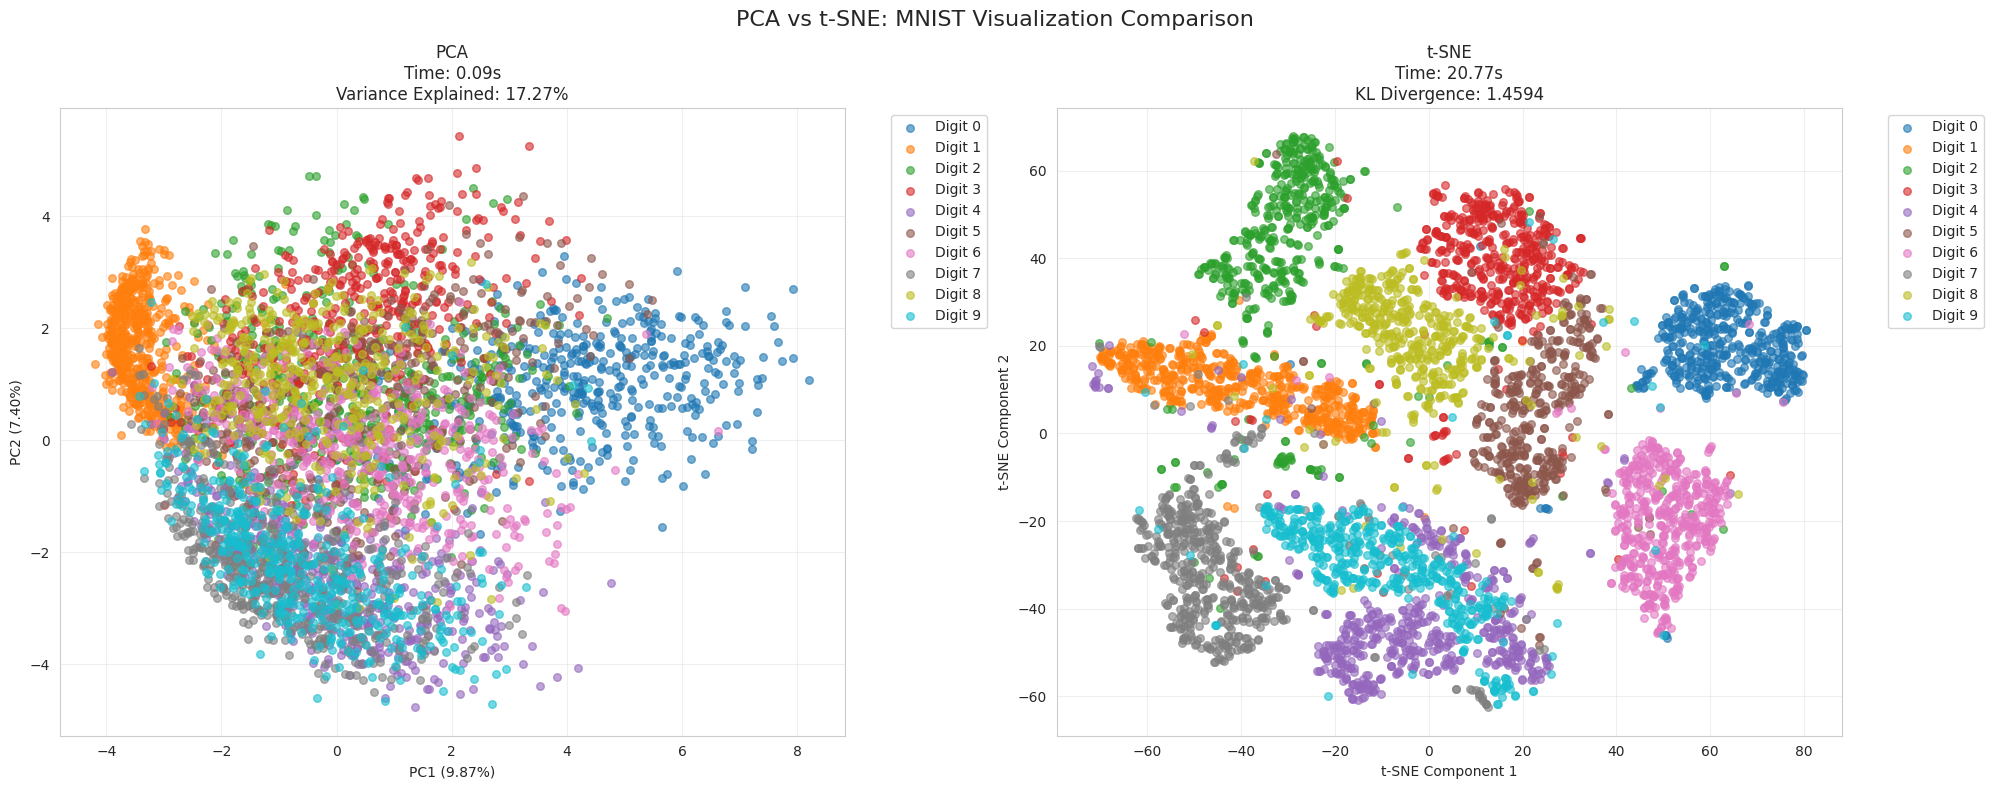

In [13]:
# Direct comparison
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

colors = plt.cm.tab10(np.linspace(0, 1, 10))

# PCA
for digit in range(10):
    mask = y_subset == digit
    axes[0].scatter(
        X_pca_2d[mask, 0],
        X_pca_2d[mask, 1],
        c=[colors[digit]],
        label=f'Digit {digit}',
        alpha=0.6,
        s=30
    )

axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%})')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%})')
axes[0].set_title(f'PCA\nTime: {pca_time:.2f}s\nVariance Explained: {pca_2d.explained_variance_ratio_.sum():.2%}')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].grid(True, alpha=0.3)

# t-SNE
for digit in range(10):
    mask = y_subset == digit
    axes[1].scatter(
        X_tsne[mask, 0],
        X_tsne[mask, 1],
        c=[colors[digit]],
        label=f'Digit {digit}',
        alpha=0.6,
        s=30
    )

axes[1].set_xlabel('t-SNE Component 1')
axes[1].set_ylabel('t-SNE Component 2')
axes[1].set_title(f't-SNE\nTime: {tsne_time:.2f}s\nKL Divergence: {tsne.kl_divergence_:.4f}')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.suptitle('PCA vs t-SNE: MNIST Visualization Comparison', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

## 11. PCA as Preprocessing for t-SNE

A common practice is to use PCA first to reduce dimensionality, then apply t-SNE for visualization.

In [14]:
# Apply PCA to 50 dimensions first, then t-SNE
print("Applying PCA (50 components) + t-SNE...")
start_time = time.time()

# PCA to 50 dimensions
pca_prep = PCA(n_components=50, random_state=42)
X_pca_prep = pca_prep.fit_transform(X_normalized)

print(f"PCA to 50D completed. Variance explained: {pca_prep.explained_variance_ratio_.sum():.4f}")

# t-SNE on PCA-reduced data
tsne_on_pca = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne_on_pca = tsne_on_pca.fit_transform(X_pca_prep)

combined_time = time.time() - start_time

print(f"PCA + t-SNE completed in {combined_time:.2f} seconds")
print(f"t-SNE KL divergence: {tsne_on_pca.kl_divergence_:.4f}")

Applying PCA (50 components) + t-SNE...
PCA to 50D completed. Variance explained: 0.8291
PCA + t-SNE completed in 17.92 seconds
t-SNE KL divergence: 1.4174


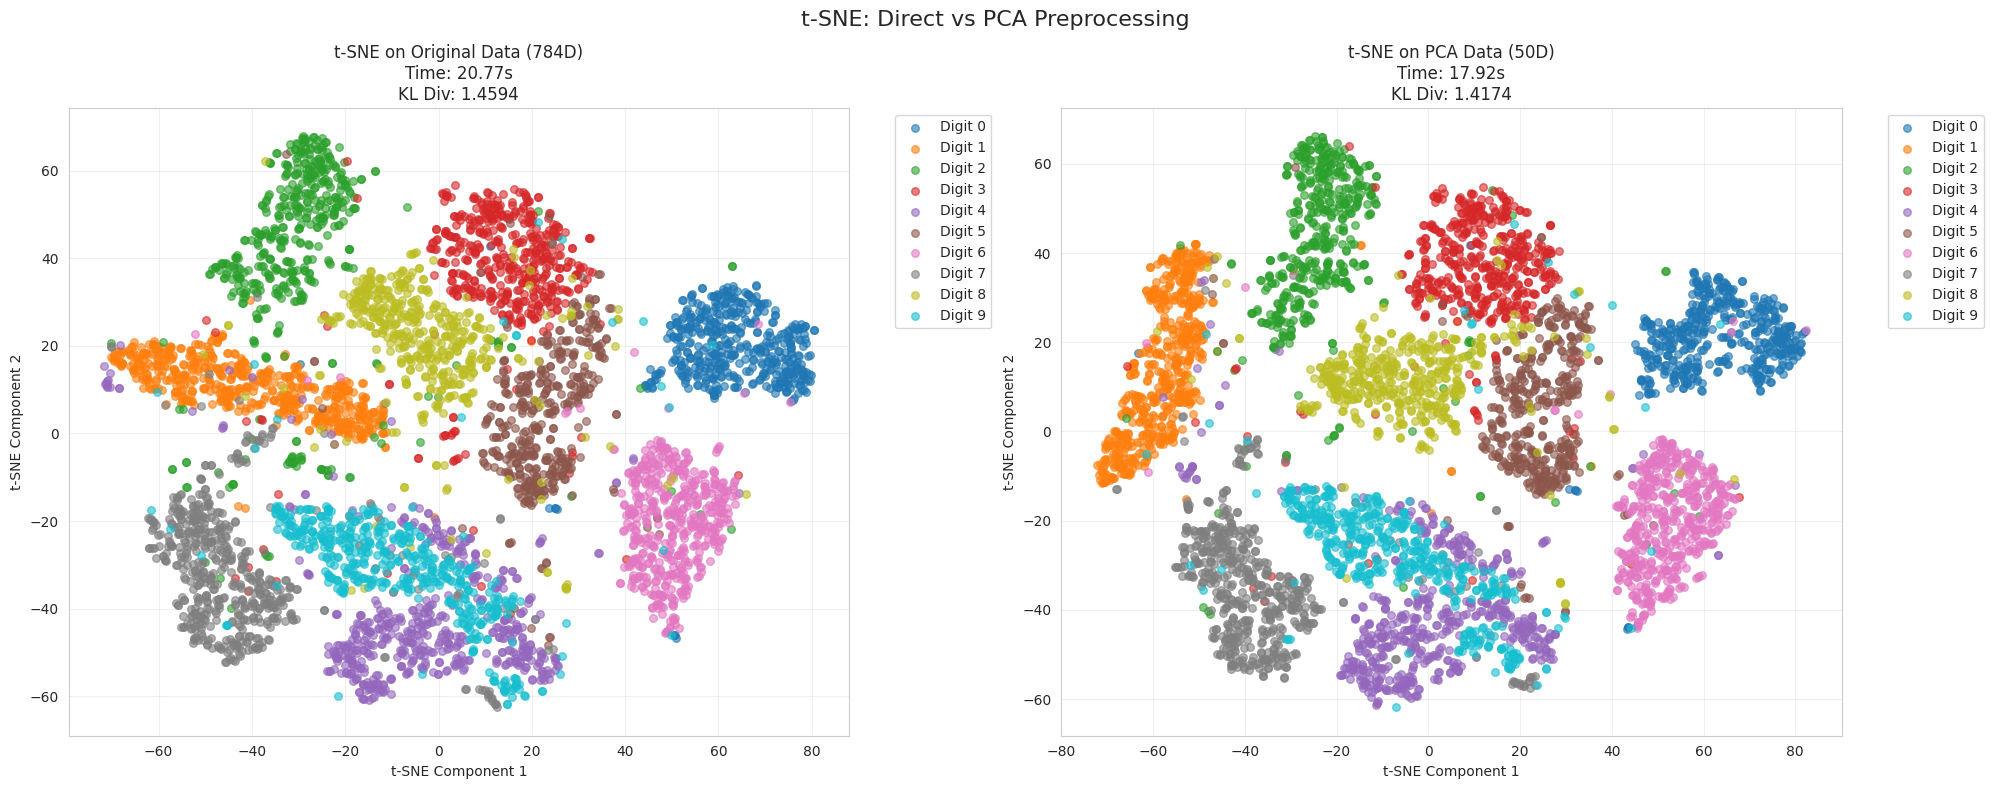


Speed improvement: 1.16x faster with PCA preprocessing


In [15]:
# Compare t-SNE with and without PCA preprocessing
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

colors = plt.cm.tab10(np.linspace(0, 1, 10))

# t-SNE directly on data
for digit in range(10):
    mask = y_subset == digit
    axes[0].scatter(
        X_tsne[mask, 0],
        X_tsne[mask, 1],
        c=[colors[digit]],
        label=f'Digit {digit}',
        alpha=0.6,
        s=30
    )

axes[0].set_xlabel('t-SNE Component 1')
axes[0].set_ylabel('t-SNE Component 2')
axes[0].set_title(f't-SNE on Original Data (784D)\nTime: {tsne_time:.2f}s\nKL Div: {tsne.kl_divergence_:.4f}')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].grid(True, alpha=0.3)

# t-SNE on PCA-reduced data
for digit in range(10):
    mask = y_subset == digit
    axes[1].scatter(
        X_tsne_on_pca[mask, 0],
        X_tsne_on_pca[mask, 1],
        c=[colors[digit]],
        label=f'Digit {digit}',
        alpha=0.6,
        s=30
    )

axes[1].set_xlabel('t-SNE Component 1')
axes[1].set_ylabel('t-SNE Component 2')
axes[1].set_title(f't-SNE on PCA Data (50D)\nTime: {combined_time:.2f}s\nKL Div: {tsne_on_pca.kl_divergence_:.4f}')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.suptitle('t-SNE: Direct vs PCA Preprocessing', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

print(f"\nSpeed improvement: {tsne_time / combined_time:.2f}x faster with PCA preprocessing")